In [1]:
import pandas as pd
import mne

In [2]:
# read .vmrk file to read the annotations  
folder = "E:\ecf-exp2-notif-mmn\data\Processed\sub002"
EEG_file = "\EEG\sub002_saurabh_NET.vmrk"
eeg_anno = mne.read_annotations(folder+EEG_file)

# convert to dataframe format
eeg_anno= eeg_anno.to_data_frame()

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\E'
C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_8008\3736183431.py:2: SyntaxWarning: invalid escape sequence '\e'
  folder = "E:\ecf-exp2-notif-mmn\data\Processed\sub002"
C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_8008\3736183431.py:3: SyntaxWarning: invalid escape sequence '\E'
  EEG_file = "\EEG\sub002_saurabh_NET.vmrk"


Finding 'sfreq' from header file: E:\ecf-exp2-notif-mmn\data\Processed\sub002\EEG\sub002_saurabh_NET.vhdr


In [3]:
# visualization 
eeg_anno.info()
eeg_anno.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2897 entries, 0 to 2896
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   onset        2897 non-null   datetime64[ns]
 1   duration     2897 non-null   float64       
 2   description  2897 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 68.0+ KB


,onset,duration,description
0,1970-01-01 00:00:00.000,0.002,New Segment/
1,1970-01-01 00:00:05.320,0.002,New Segment/
2,1970-01-01 00:00:05.850,0.002,Stimulus/S 14
3,1970-01-01 00:00:06.384,0.002,Stimulus/S 16
4,1970-01-01 00:00:07.068,0.002,Stimulus/S 14


In [4]:
eeg_anno['marker'] = eeg_anno['description'].str.replace("Stimulus/S ","")
eeg_anno.info()
eeg_anno.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2897 entries, 0 to 2896
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   onset        2897 non-null   datetime64[ns]
 1   duration     2897 non-null   float64       
 2   description  2897 non-null   object        
 3   marker       2897 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 90.7+ KB


,onset,duration,description,marker
0,1970-01-01 00:00:00.000,0.002,New Segment/,New Segment/
1,1970-01-01 00:00:05.320,0.002,New Segment/,New Segment/
2,1970-01-01 00:00:05.850,0.002,Stimulus/S 14,14
3,1970-01-01 00:00:06.384,0.002,Stimulus/S 16,16
4,1970-01-01 00:00:07.068,0.002,Stimulus/S 14,14


In [5]:
# Read_LM file for the marker in the Emotibit 
emotibit_LM_marker = "\Emotibit\\2024-05-14_12-39-56-615095_LM.csv"
emotibit_marker  = pd.read_csv(folder+emotibit_LM_marker)
emotibit_marker.head()

<>:2: SyntaxWarning: invalid escape sequence '\E'
<>:2: SyntaxWarning: invalid escape sequence '\E'
C:\Users\CSNDLab\AppData\Local\Temp\ipykernel_8008\3500052441.py:2: SyntaxWarning: invalid escape sequence '\E'
  emotibit_LM_marker = "\Emotibit\\2024-05-14_12-39-56-615095_LM.csv"


,LocalTimestamp,EmotiBitTimestamp,PacketNumber,DataLength,TypeTag,ProtocolVersion,DataReliability,LR,LM,LC,LD,Unnamed: 11
0,1.715671e+09,2121549,19164,8,LM,1,100,486187.400511,2.231512e+06,486187.405359,14,NaN
1,1.715671e+09,2122589,19336,8,LM,1,100,486187.933848,2.231512e+06,486187.939144,16,NaN
2,1.715671e+09,2122711,19356,8,LM,1,100,486188.667164,2.231513e+06,486188.671779,14,NaN
3,1.715671e+09,2123309,19460,8,LM,1,100,486189.184489,2.231513e+06,486189.205942,16,NaN
4,1.715671e+09,2124058,19579,8,LM,1,100,486189.983835,2.231514e+06,486190.004851,14,NaN


In [6]:
emotibit_marker.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2523 entries, 0 to 2522
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LocalTimestamp     2523 non-null   float64
 1   EmotiBitTimestamp  2523 non-null   int64  
 2   PacketNumber       2523 non-null   int64  
 3   DataLength         2523 non-null   int64  
 4   TypeTag            2523 non-null   object 
 5   ProtocolVersion    2523 non-null   int64  
 6   DataReliability    2523 non-null   int64  
 7   LR                 2523 non-null   float64
 8   LM                 2523 non-null   float64
 9   LC                 2523 non-null   float64
 10  LD                 2523 non-null   int64  
 11  Unnamed: 11        0 non-null      float64
dtypes: float64(5), int64(6), object(1)
memory usage: 236.7+ KB


In [7]:
emotibit_marker_b2 =emotibit_marker.loc[emotibit_marker["LD"].astype('str').eq('21').cummax()].reset_index()
emotibit_marker_b2.head()

,index,LocalTimestamp,EmotiBitTimestamp,PacketNumber,DataLength,TypeTag,ProtocolVersion,DataReliability,LR,LM,LC,LD,Unnamed: 11
0,1551,1.715672e+09,3203522,290,8,LM,1,100,487321.596270,2.232646e+06,487321.616750,21,NaN
1,1552,1.715672e+09,3204772,498,8,LM,1,100,487322.928920,2.232647e+06,487322.949834,25,NaN
2,1553,1.715672e+09,3205287,582,8,LM,1,100,487323.462360,2.232648e+06,487323.482960,28,NaN
3,1554,1.715672e+09,3206023,702,8,LM,1,100,487324.245723,2.232649e+06,487324.249260,25,NaN
4,1555,1.715672e+09,3206512,786,8,LM,1,100,487324.745757,2.232649e+06,487324.749552,28,NaN


In [8]:
emotibit_marker_b2['LD'] = emotibit_marker_b2['LD'].astype('int')
eeg_anno_b2 =eeg_anno.loc[eeg_anno["marker"].astype('str').eq('21').cummax()].reset_index()
eeg_anno_b2['marker'] = eeg_anno_b2['marker'].astype('int')
eeg_anno_b2.head()

,index,onset,duration,description,marker
0,1355,1970-01-01 00:16:47.618,0.002,Stimulus/S 21,21
1,1356,1970-01-01 00:16:48.952,0.002,Stimulus/S 25,25
2,1357,1970-01-01 00:16:49.484,0.002,Stimulus/S 28,28
3,1358,1970-01-01 00:16:50.268,0.002,Stimulus/S 25,25
4,1359,1970-01-01 00:16:50.768,0.002,Stimulus/S 28,28


In [9]:
emotibit_marker_b2.info()
eeg_anno_b2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972 entries, 0 to 971
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              972 non-null    int64  
 1   LocalTimestamp     972 non-null    float64
 2   EmotiBitTimestamp  972 non-null    int64  
 3   PacketNumber       972 non-null    int64  
 4   DataLength         972 non-null    int64  
 5   TypeTag            972 non-null    object 
 6   ProtocolVersion    972 non-null    int64  
 7   DataReliability    972 non-null    int64  
 8   LR                 972 non-null    float64
 9   LM                 972 non-null    float64
 10  LC                 972 non-null    float64
 11  LD                 972 non-null    int32  
 12  Unnamed: 11        0 non-null      float64
dtypes: float64(5), int32(1), int64(6), object(1)
memory usage: 95.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 5 column

In [17]:
combine =  pd.DataFrame(eeg_anno_b2)
combine[["LD",'LocalTimestamp', 'EmotiBitTimestamp']] =emotibit_marker_b2[['LD','LocalTimestamp', 'EmotiBitTimestamp']] 
combine.head()

,index,onset,duration,description,marker,LD,LocalTimestamp,EmotiBitTimestamp
0,1355,1970-01-01 00:16:47.618,0.002,Stimulus/S 21,21,21.0,1.715672e+09,3203522.0
1,1356,1970-01-01 00:16:48.952,0.002,Stimulus/S 25,25,25.0,1.715672e+09,3204772.0
2,1357,1970-01-01 00:16:49.484,0.002,Stimulus/S 28,28,28.0,1.715672e+09,3205287.0
3,1358,1970-01-01 00:16:50.268,0.002,Stimulus/S 25,25,25.0,1.715672e+09,3206023.0
4,1359,1970-01-01 00:16:50.768,0.002,Stimulus/S 28,28,28.0,1.715672e+09,3206512.0


In [18]:
combine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1542 entries, 0 to 1541
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   index              1542 non-null   int64         
 1   onset              1542 non-null   datetime64[ns]
 2   duration           1542 non-null   float64       
 3   description        1542 non-null   object        
 4   marker             1542 non-null   int32         
 5   LD                 972 non-null    float64       
 6   LocalTimestamp     972 non-null    float64       
 7   EmotiBitTimestamp  972 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int32(1), int64(1), object(1)
memory usage: 90.5+ KB


In [29]:
import numpy as np
combine["eeg_ms"] = combine['onset'].astype(np.int64) / int(1e6)

combine.tail()


,index,onset,duration,description,marker,LD,LocalTimestamp,EmotiBitTimestamp,eeg_ms
1537,2892,1970-01-01 00:36:03.436,0.002,Stimulus/S 25,25,NaN,NaN,NaN,2163436.0
1538,2893,1970-01-01 00:36:03.952,0.002,Stimulus/S 28,28,NaN,NaN,NaN,2163952.0
1539,2894,1970-01-01 00:36:04.704,0.002,Stimulus/S 25,25,NaN,NaN,NaN,2164704.0
1540,2895,1970-01-01 00:36:05.236,0.002,Stimulus/S 28,28,NaN,NaN,NaN,2165236.0
1541,2896,1970-01-01 00:36:06.670,0.002,Stimulus/S 21,21,NaN,NaN,NaN,2166670.0


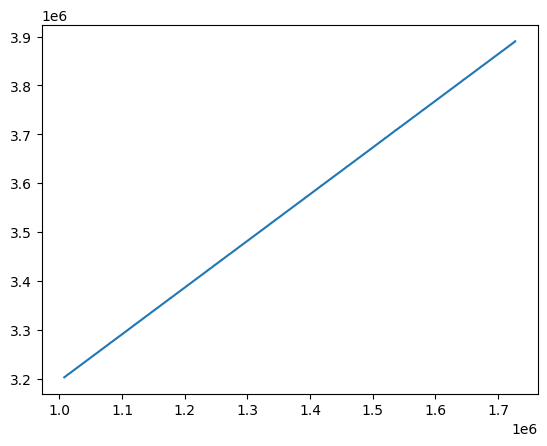

In [31]:
import matplotlib.pyplot as plt
plt.plot(combine["eeg_ms"],combine['EmotiBitTimestamp'])